<h1 style="color:Green;">GlobalMart Sales Analysis: Exploratory Data Analysis (EDA)</h1>
<h4 style="color:black;">This project performs an exploratory data analysis (EDA) on GlobalMart's retail dataset to understand sales perfomance, profitability, product trends, and regional  distribution. The goal is to generate actionable insights to support data-driven business decisions.</h4>

<h3 style="color:blue;"> Objectives</h3>
<p style="color:black;"> 1. Analyze overall sales and profit performance</p>
<p style="color:black;"> 2. Identify top-performing products and regions</p>
<p style="color:black;"> 3. Examine relationships between sales, profit, and discount</p>
<p style="color:black;"> 4. Explore time-based trends and seasonality</p>
<p style="color:black;"> 5. Generate insights to support strategic decision-making</p>

<h3 style="color:blue;">Import Libraries</h3>
<h4 style="colr:black;">The following libraries are used for  data manipulation, analysis , and visualization.</h4>

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

<h3 style="color:blue;">Data Loading and Exploration </h3>

df = pd.read_csv("C:/Users/Owner/OneDrive/Desktop/RAW DATA for Analysis/Global_Superstore.csv")
df.head()
df.shape
df.info()
df.describe()

<h3 style="color:blue;">Data Cleaning</h3>

In [44]:
#Check missing values
df.isnull().sum()

#Drop missing values
df.dropna(inplace=True)

#convert Order Date and Ship Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


<h3 style="color:blue;">Key Metrics</h3>

In [49]:
# Calculate Total Sales and Total Profit
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print(f"Total Sales:{total_sales}, Total Profit:{total_profit}")

Total Sales:54535.08, Total Profit:12063.97


<h3 style="color:blue;">Exploratoty Data Analysis (EDA)</h3>
<h4 style="color:black;">Top Performing Products</h4>
<p style="color:black;">Identifying the highest revenue-generating products</p>
<h4 style="color:black;">The top products contribute significantly to total revenue, indicating key drivers of business performance.</h4>

In [57]:
# top 10 products by sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

Product Name
GBC Ibimaster 500 Manual ProClick Binding System           9892.74
GBC DocuBind P400 Electric Binding System                  4355.17
Canon Image Class D660 Copier                              2999.95
GBC DocuBind 300 Electric Binding Machine                  2419.51
Hon 5100 Series Wood Tables                                2036.86
Bady BDG101FRU Card Printer                                1439.98
Avaya IP Phone 1140E VoIP phone                            1394.95
Global Adaptabilites Bookcase, Cherry/Storm Gray Finish    1292.94
Tennsco Single-Tier Lockers                                1126.02
Ibico Ibimaster 300 Manual Binding System                  1103.97
Name: Sales, dtype: float64


<h3 style="color:blue;">Sales by Region</h3>
<p style="color:black;">Analysis of regional sales performance</p>

In [62]:
sales_by_region = df.groupby('Region')['Sales'].sum()
print(sales_by_region)

Region
Central US     17187.94
Eastern US     12256.44
Southern US     8360.75
Western US     16729.95
Name: Sales, dtype: float64


<h3 style="color:blue;"> Sales Vs Profit</h3>
<p style="color:black;">Examining relationship between Sales and Profit</p>

In [67]:
# Correlation between Sales and Profit
correlation = df['Sales'].corr(df['Profit'])

print(f"correlation between Sales and Profit:{correlation}")

correlation between Sales and Profit:0.9313979948257132


<h3 style="color:blue;">Discount Vs Profit</h3>
<p style="color:black;">1.Calculating Total Discount and Total Profit</p>
<p style="color:black;">2.Evaluate the impact of discounting on profitability</p>

In [84]:
total_discount = df['Discount'].sum()
total_profit = df['Profit'].sum()

print(f"Total Discount:{total_discount}, Total Profit:{total_profit}")

#Convert "Discount" and "Profit" columns to numeric
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

#Calculate the correlation between discount and profit
discount_profit_correlation = df[['Discount', 'Profit']].corr().iloc[0,1]
total_discount, total_profit, discount_profit_correlation

Total Discount:29.95, Total Profit:12063.97


(29.95, 12063.97, -0.16262271039478665)

<h4 style="color:black;">A weak negative correlation indicates that higher discount may slightly reduce profitability.</h4>

<h3 style="color:blue;">Visualization</h3>

<h4 style="color:black;">Sales by Category (Bar Chart)</h4>
<p style="colr:black;">This Bar Chart shows a visual comparison of sales across product categories.</p>

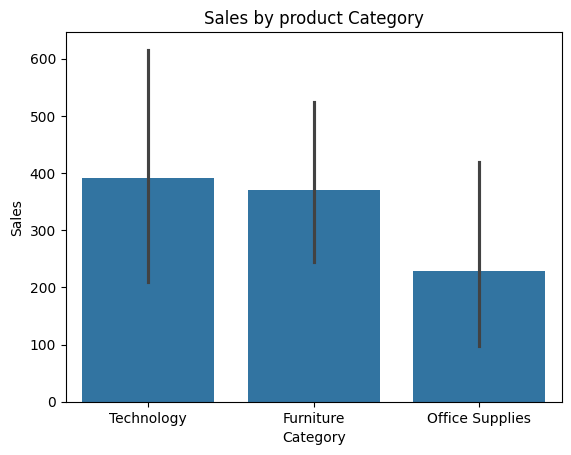

In [90]:
# Bar plot of Sales by product Category
sns.barplot(x='Category', y='Sales', data=df)
plt.title('Sales by product Category')
plt.show()

<p style="color:black;">Certain categories outperform others, highlighting key revenue segments.</p>

<h3 Style="color:blue;">Monthly Sales Trend</h3>
<h4 style="color:black;">Time series analysis of sales performance</h4>

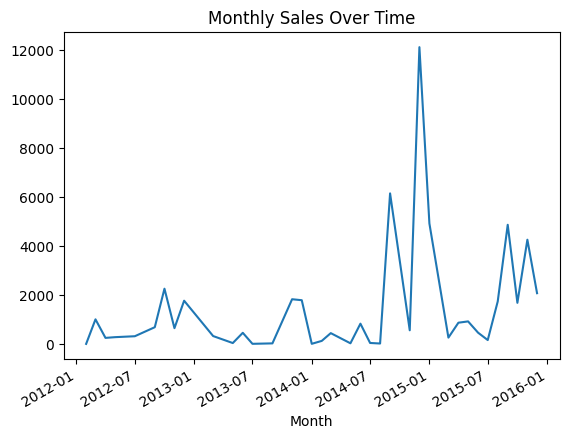

In [100]:
# Create a new 'month' column from Order Date
df['Month'] = df['Order Date'].dt.to_period('M')

#Calculate monthly sales
monthly_sales = df.groupby('Month')['Sales'].sum()

#Ensure the index is in datetime format for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

# plot monthly sales over time
monthly_sales.plot(kind = 'line')
plt.title('Monthly Sales Over Time')
plt.show()

<p style="color:black;">Sales fluctuate over time,indicating possible seasonal pattern.</p>

<h3 style="color:blue;">Scatter Plot (Sales Vs Profit)</h3>
<h4 style="color:black;">Visualizing the relationship between Sales and Profit</h4>

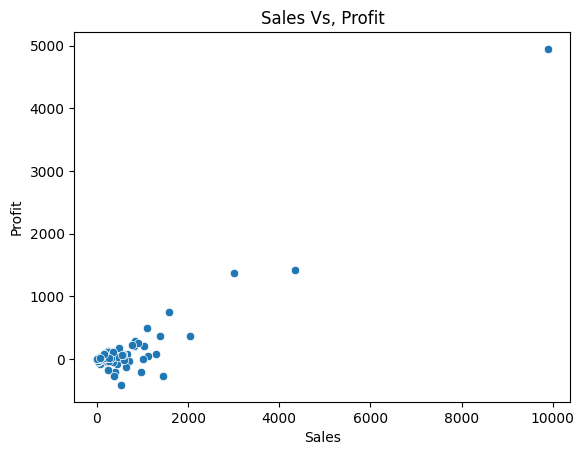

In [104]:
#Scatter plot of Sales Vs. Profit
sns.scatterplot(x = 'Sales', y='Profit', data = df)
plt.title('Sales Vs, Profit')
plt.show()

<p style="color:black;">Most data points follow apositive trend, with a few outliers indicating inefficiencies.</p>

<h3 style="color:blue;">HeatMap</h3>
<h4 style="color:black;">Regional and Category performance</h4>
<p style="color:black;">Heatmap showing sales distribution across regions and categories</p>

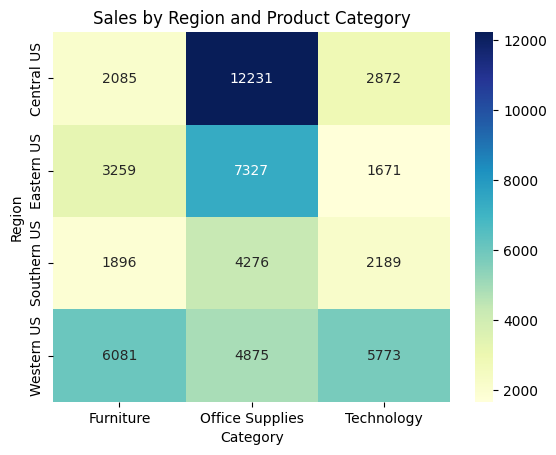

In [110]:
# Pivot table for sales by Region and product Category
pivot_table = df.pivot_table(values = 'Sales', index = 'Region', columns = 'Category', aggfunc = 'sum')

#Heatmap of Sales by Region and product Category
sns.heatmap(pivot_table, annot = True, fmt = '.0f', cmap = 'YlGnBu')
plt.title('Sales by Region and Product Category')
plt.show()

<p style="color:black;">The heatmap highlights strong and weak performing combinations for strategic focus</p>

<h3 style="color:blue;">Time Series Decomposition</h3>
<h4 style="color:black;">Breaking down sales into trend, seasonal, and residue components.</h4>

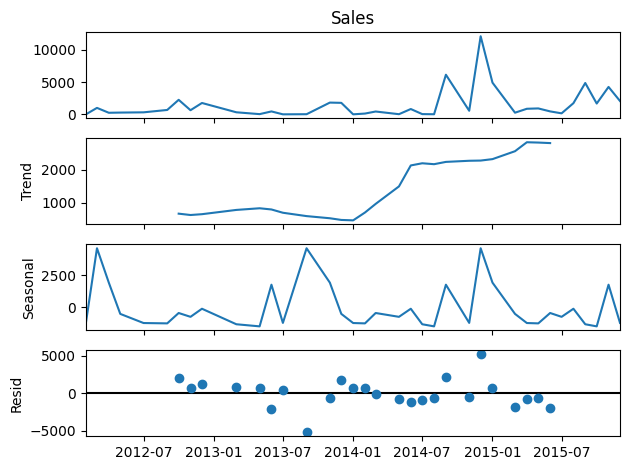

In [114]:
#Seasonal Decomposition of time series(monthly sales)
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(monthly_sales, model='additive', period = 12)
result.plot()
plt.show()

<p style="color:black;"> The decomposition  confirms the presence of seasonal pattern and underlying trends.</p>

<h3 style="color:blue;">Key Findings</h3>
<p style="color:black;">-Strong positive relationship between sales and profit</p>
<p style="color:black;">-Discounts have a slight negative impact on profitability</p>
<p style="color:black;">-Certain products dominate revenue generation</p>
<p style="color:black;">-Regional performance varies significantly</p>
<p style="color:black;">-Sales exhibit seasonal trends</p>

<h3 style="color:blue;">Implications</h3>
<p style="color:black;">The findings suggest opportunities to optimize pricing strategies, improve regional performance, and leverage seasonal trends for better planning.</p>

<h3 style="color:blue;"> Recommendations</h3>
<p style="color:black;"> 1.Focus on high-performing products</p>
<p style="color:black;"> 2.Optimise discount strategies</p>
<p style="color:black;"> 3.Target underperforming regions</p>
<p style="color:black;"> 4.Use seasonal insights for forecasting</p>

<h3 style="color:blue;">Conclusion</h3>
<p style="color:black;">This analysis provides valuable insights into sales performance, profitability, and business trends. The findings support data-driven decision-making to enhance revenue and operational efficiency.</p>